# Entrenamiento del Modelo y scalare Predicredito

### librerias

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns

### Creacion Datos Sinteticos

In [5]:
def generar_dataset_perfectamente_balanceado(n_por_seed=3000, seeds=8):
    dfs = []
    for seed in range(seeds):
        np.random.seed(seed)
        n = n_por_seed

        # Generamos perfiles base
        tipos = np.random.choice(["bajo", "medio", "alto"], size=n, p=[0.33, 0.33, 0.34])

        data = []
        for t in tipos:
            # (Mantenemos tu lógica de generación de variables financieras...)
            if t == "bajo":
                p_crediticio = np.random.normal(820, 40); ingresos = np.random.normal(6000000, 500000)
                endeudamiento = np.random.normal(15, 5); antiguedad = np.random.normal(60, 10)
                ahorros = np.random.normal(15000000, 2000000); mora_6m = 0; uso_tarjeta = np.random.uniform(5, 25)
            elif t == "medio":
                p_crediticio = np.random.normal(640, 50); ingresos = np.random.normal(3500000, 700000)
                endeudamiento = np.random.normal(45, 10); antiguedad = np.random.normal(30, 8)
                ahorros = np.random.normal(4000000, 1000000); mora_6m = np.random.poisson(0.7); uso_tarjeta = np.random.uniform(30, 60)
            else:
                p_crediticio = np.random.normal(400, 60); ingresos = np.random.normal(1800000, 500000)
                endeudamiento = np.random.normal(75, 12); antiguedad = np.random.normal(8, 5)
                ahorros = np.random.normal(800000, 400000); mora_6m = np.random.poisson(2.2); uso_tarjeta = np.random.uniform(65, 98)

            data.append([p_crediticio, ingresos, endeudamiento, antiguedad, ahorros, mora_6m, uso_tarjeta])

        df = pd.DataFrame(data, columns=['puntaje_crediticio', 'ingresos_mensuales', 'nivel_endeudamiento',
                                        'antiguedad_laboral', 'saldo_ahorros', 'atrasos_6_meses', 'pct_uso_credito'])

        # Añadir ruido
        df['edad_cliente'] = np.random.randint(18, 75, size=n)
        df['n_hijos'] = np.random.randint(0, 5, size=n)

        # --- ESTRATEGIA DE BALANCEO PERFECTO ---
        # 1. Calculamos un score continuo de riesgo
        df['puntuacion_tecnica'] = (
            (df['nivel_endeudamiento'] * 0.3) +
            (df['pct_uso_credito'] * 0.2) +
            (df['atrasos_6_meses'] * 15) -
            (df['puntaje_crediticio'] * 0.1) -
            (df['antiguedad_laboral'] * 0.5)
        )

        # 2. Usamos pd.qcut para dividir en 3 grupos con la MISMA cantidad de datos
        # Esto garantiza que el riesgo 0, 1 y 2 tengan el mismo peso.
        df['riesgo_target'] = pd.qcut(df['puntuacion_tecnica'], q=3, labels=[0, 1, 2]).astype(int)

        # Eliminamos la columna técnica para que el modelo no haga "trampa"
        df = df.drop('puntuacion_tecnica', axis=1)

        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

df = generar_dataset_perfectamente_balanceado()
print("Distribución de Clases (Perfecta):")
print(df['riesgo_target'].value_counts(normalize=True))

Distribución de Clases (Perfecta):
riesgo_target
1    0.333333
2    0.333333
0    0.333333
Name: proportion, dtype: float64


### Creacion del Scaler

In [6]:
def escalar_datos_credito(df, columna_target='riesgo_target'):
    """
    Toma un DataFrame, escala las variables numéricas entre 0 y 1
    y mantiene la columna de riesgo intacta.
    """
    # 1. Crear una copia para no modificar el original
    df_resultado = df.copy()

    # 2. Identificar las columnas a escalar (todas menos el target)
    columnas_para_escalar = [col for col in df.columns if col != columna_target]

    # 3. Configurar el escalador (MinMaxScaler)
    # Basado en los indicadores: Puntaje, Ingresos, Endeudamiento y Antigüedad
    scaler = MinMaxScaler()

    # 4. Aplicar la transformación
    df_resultado[columnas_para_escalar] = scaler.fit_transform(df[columnas_para_escalar])

    return df_resultado, scaler

df_listo_para_modelo, mi_escalador = escalar_datos_credito(df)

### Seleccion de Variables

In [7]:
""" en esta seccion analizamos que tan importantes son las variable spara la generacion del riesgo"""
def seleccionar_variables_por_consenso_escalado(df_norm, n_top=7):
    X_temp = df_norm.drop('riesgo_target', axis=1)
    y_temp = df_norm['riesgo_target']
    features = X_temp.columns

    scaler_imp = MinMaxScaler()

    # 1. Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_temp, y_temp)
    imp_rf = scaler_imp.fit_transform(rf.feature_importances_.reshape(-1, 1)).flatten()

    # 2. Gradient Boosting
    gb = GradientBoostingClassifier(random_state=42).fit(X_temp, y_temp)
    imp_gb = scaler_imp.fit_transform(gb.feature_importances_.reshape(-1, 1)).flatten()

    # 3. Regresión Logística (con max_iter aumentado)
    lr = LogisticRegression(max_iter=5000, random_state=42).fit(X_temp, y_temp)
    coef_abs = np.abs(lr.coef_).mean(axis=0)
    imp_lr = scaler_imp.fit_transform(coef_abs.reshape(-1, 1)).flatten()

    # Crear el DataFrame de votos
    df_votos = pd.DataFrame({
        'Variable': features,
        'RF_Puntaje': imp_rf,
        'GB_Puntaje': imp_gb,
        'LR_Puntaje': imp_lr
    })

    # Calcular promedio y ordenar
    df_votos['Promedio_Consenso'] = df_votos[['RF_Puntaje', 'GB_Puntaje', 'LR_Puntaje']].mean(axis=1)
    df_votos = df_votos.sort_values(by='Promedio_Consenso', ascending=False)

    # --- NUEVA SECCIÓN DE IMPRESIÓN ---
    print("\n" + "="*60)
    print("RANKING MULTI-MODELO DE VARIABLES (0 a 1)")
    print("="*60)
    # Mostramos todas las filas y redondeamos a 4 decimales para que se vea limpio
    print(df_votos.to_string(index=False, float_format=lambda x: "{:.4f}".format(x)))
    print("="*60)

    mejores_vars = df_votos.head(n_top)['Variable'].tolist()
    print(f"TOP {n_top} SELECCIONADO: {mejores_vars}\n")

    return df_votos, mejores_vars

# --- USO ---
tabla_votos, mejores_vars = seleccionar_variables_por_consenso_escalado(df_listo_para_modelo, n_top=7)

# 2. Ahora sí, filtramos el DataFrame para quedarnos SOLO con las variables ganadoras y el target
df_final = df_listo_para_modelo[mejores_vars + ['riesgo_target']]

# 3. Mostrar resultados para verificar
print("--- Tabla de Votación Ponderada ---")
print(tabla_votos[['Variable', 'Promedio_Consenso']].head(7))
print(f"Dataset final listo con {len(mejores_vars)} variables seleccionadas.")


RANKING MULTI-MODELO DE VARIABLES (0 a 1)
           Variable  RF_Puntaje  GB_Puntaje  LR_Puntaje  Promedio_Consenso
    pct_uso_credito      1.0000      1.0000      0.3608             0.7869
 puntaje_crediticio      0.6830      0.0211      0.7763             0.4935
    atrasos_6_meses      0.0833      0.0253      1.0000             0.3695
      saldo_ahorros      0.6702      0.0006      0.2696             0.3135
 antiguedad_laboral      0.1695      0.0034      0.6191             0.2640
nivel_endeudamiento      0.2413      0.0021      0.4508             0.2314
 ingresos_mensuales      0.3933      0.0006      0.1530             0.1823
       edad_cliente      0.0062      0.0001      0.0000             0.0021
            n_hijos      0.0000      0.0000      0.0046             0.0015
TOP 7 SELECCIONADO: ['pct_uso_credito', 'puntaje_crediticio', 'atrasos_6_meses', 'saldo_ahorros', 'antiguedad_laboral', 'nivel_endeudamiento', 'ingresos_mensuales']

--- Tabla de Votación Ponderada ---
     

### Entrenamiento del modelo Y medicion de cada Modelo

In [8]:
# 1. Definir X (variables elegidas) e y (objetivo)
X = df_final.drop('riesgo_target', axis=1)
y = df_final['riesgo_target']

# 2. División Entrenamiento/Prueba (80/20) con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Diccionario de Modelos (con el max_iter corregido)
modelos_finales = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

resultados_evaluacion = []

print("--- Entrenando y Evaluando Modelos ---")

for nombre, modelo in modelos_finales.items():
    # Medir tiempo
    inicio = time.time()

    # Validación Cruzada (para ver la estabilidad/varianza)
    cv_scores = cross_val_score(modelo, X_train, y_train, cv=5)

    # Entrenamiento
    modelo.fit(X_train, y_train)
    tiempo_entrenamiento = time.time() - inicio

    # Predicción sobre los datos de TEST
    y_pred = modelo.predict(X_test)

    # Cálculo de métricas
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    varianza = cv_scores.std() * 100 # Qué tanto desvaría el modelo

    resultados_evaluacion.append({
        "Modelo": nombre,
        "Accuracy (Test)": f"{acc*100:.2f}%",
        "F1-Score": f"{f1*100:.2f}%",
        "Varianza (CV Std)": f"{varianza:.4f}%",
        "Tiempo (s)": round(tiempo_entrenamiento, 4)
    })

# 4. Crear DataFrame comparativo
df_ranking = pd.DataFrame(resultados_evaluacion).sort_values(by="Accuracy (Test)", ascending=False)

print("\n" + "="*70)
print("TABLA COMPARATIVA DE RENDIMIENTO FINAL")
print("="*70)
print(df_ranking.to_string(index=False))
print("="*70)

--- Entrenando y Evaluando Modelos ---

TABLA COMPARATIVA DE RENDIMIENTO FINAL
             Modelo Accuracy (Test) F1-Score Varianza (CV Std)  Tiempo (s)
  Gradient Boosting          98.71%   98.71%           0.1176%     78.6006
Logistic Regression          98.62%   98.62%           0.1778%      0.5529
      Random Forest          98.60%   98.60%           0.1542%     16.7282


### evaluacion grafica de los tres modelos

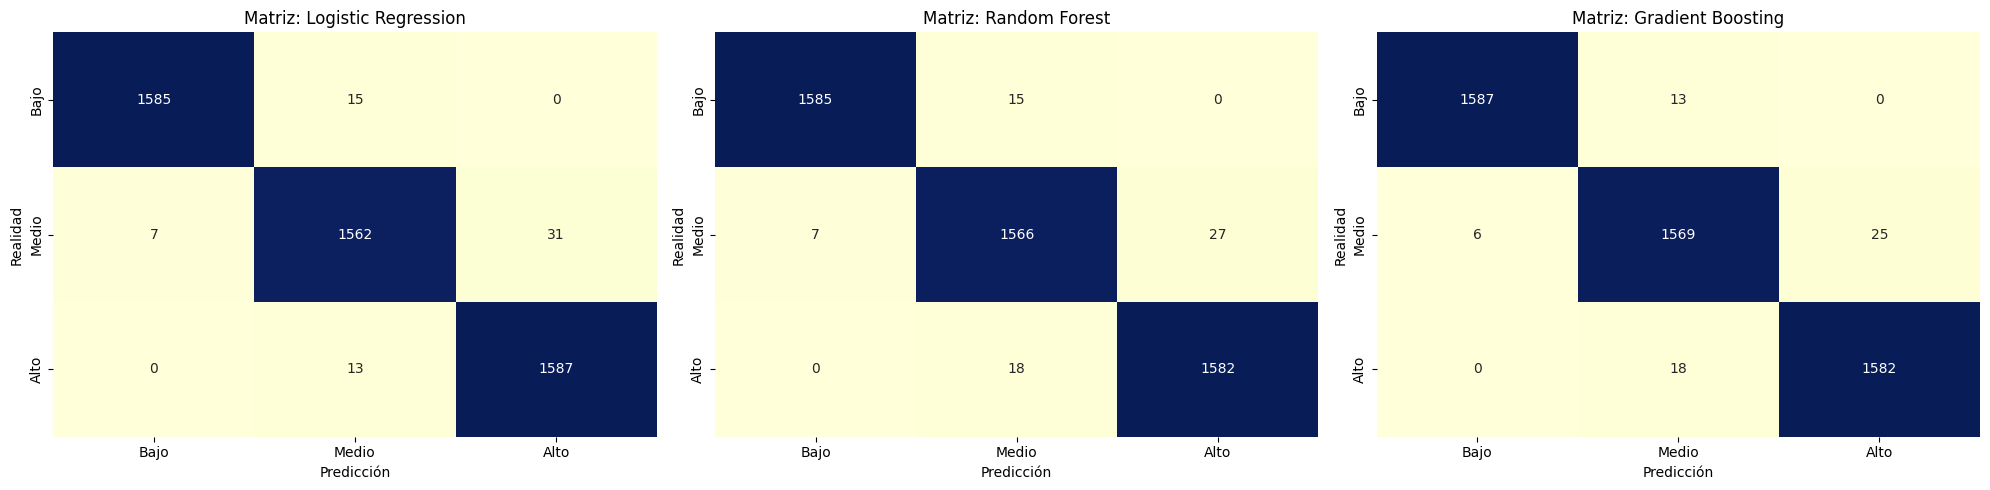

In [9]:
# Configurar el lienzo para 3 gráficas
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
labels = ['Bajo', 'Medio', 'Alto']

for i, (nombre, modelo) in enumerate(modelos_finales.items()):
    # Obtener predicciones
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    # Graficar en su respectivo lugar
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', ax=axes[i],
                xticklabels=labels, yticklabels=labels, cbar=False)

    axes[i].set_title(f'Matriz: {nombre}')
    axes[i].set_ylabel('Realidad')
    axes[i].set_xlabel('Predicción')

plt.tight_layout()
plt.show()

### eleccion del modelo

In [10]:
# 1. Obtener el modelo de Random Forest entrenado del diccionario
modelo_rf = modelos_finales["Random Forest"]

# 2. Guardar el modelo en un archivo .pkl local en Colab
nombre_archivo = "modelo.pkl"
joblib.dump(modelo_rf, nombre_archivo)
print(f"✅ Modelo guardado exitosamente como: {nombre_archivo}")

✅ Modelo guardado exitosamente como: modelo.pkl


### modificacion del scaler para eleguir solo as varibales necesarias

In [ ]:
# 1. Definir la lista exacta de las 7 variables que usas en tu App
variables_seleccionadas = [
    'pct_uso_credito',
    'puntaje_crediticio',
    'atrasos_6_meses',
    'saldo_ahorros',
    'antiguedad_laboral',
    'nivel_endeudamiento',
    'ingresos_mensuales'
]

# 2. Configurar y entrenar el nuevo escalador SOLO con estas variables
nuevo_escalador = MinMaxScaler()
nuevo_escalador.fit(df_final[variables_seleccionadas])

# 3. Exportar el nuevo escalador limpio
joblib.dump(nuevo_escalador, "scalador.pkl")

print("¡Listo! El archivo 'scalador.pkl' ha sido actualizado con éxito.")
print("Ahora solo conoce las 7 variables requeridas:", nuevo_escalador.feature_names_in_.tolist())